<a href="https://colab.research.google.com/github/GameofCodeZ/differential-cryptanalysis/blob/main/differential_crptananlysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Toy Cipher Design

The cipher used in this project is a simple **Substitution–Permutation Network (SPN)** consisting of:

1. **Substitution (S-box)** – introduces nonlinearity
2. **Permutation** – spreads bit changes across positions
3. **Key mixing (XOR with key)**

Block size: **8 bits**

This simplified cipher is intentionally small so that we can easily study its cryptographic properties.

In [1]:
# 4-bit S-box
S_BOX = {
    0x0:0x6, 0x1:0x4, 0x2:0xC, 0x3:0x5,
    0x4:0x0, 0x5:0x7, 0x6:0x2, 0x7:0xE,
    0x8:0x1, 0x9:0xF, 0xA:0x3, 0xB:0xD,
    0xC:0x8, 0xD:0xA, 0xE:0x9, 0xF:0xB
}

In [2]:
def substitute(byte):
    left = (byte >> 4) & 0xF
    right = byte & 0xF

    left = S_BOX[left]
    right = S_BOX[right]

    return (left << 4) | right

In [3]:
def permute(byte):
    bits = [(byte >> i) & 1 for i in range(8)]

    permuted = [
        bits[1],
        bits[5],
        bits[2],
        bits[0],
        bits[3],
        bits[7],
        bits[4],
        bits[6]
    ]

    result = 0
    for i in range(8):
        result |= (permuted[i] << i)

    return result

In [4]:
def encrypt(plaintext, key):

    state = plaintext ^ key

    state = substitute(state)

    state = permute(state)

    state = state ^ key

    return state


## Differential Cryptanalysis Experiment

We generate many pairs of plaintexts with a **fixed input difference**.

For each pair:

1. Encrypt both plaintexts
2. Compute the ciphertext difference
3. Record the frequency of each difference

The resulting frequency distribution reveals whether certain ciphertext differences occur more often than expected.


In [5]:
import random
from collections import defaultdict

key = random.randint(0,255)

input_difference = 0b00000001

trials = 5000

diff_counts = defaultdict(int)

for _ in range(trials):

    p1 = random.randint(0,255)
    p2 = p1 ^ input_difference

    c1 = encrypt(p1, key)
    c2 = encrypt(p2, key)

    diff = c1 ^ c2

    diff_counts[diff] += 1

In [6]:
print("Ciphertext Difference Frequencies:\n")

for diff, count in sorted(diff_counts.items()):
    print(f"{diff:08b} : {count}")

Ciphertext Difference Frequencies:

00000001 : 1841
00001101 : 659
00010100 : 608
00010101 : 1252
00011000 : 640


## Visualization of Differential Distribution

The graph below shows how frequently each ciphertext difference occurs.

If the cipher were perfectly random, all differences would appear roughly equally often. However, biases in the distribution reveal structural weaknesses that attackers can exploit.

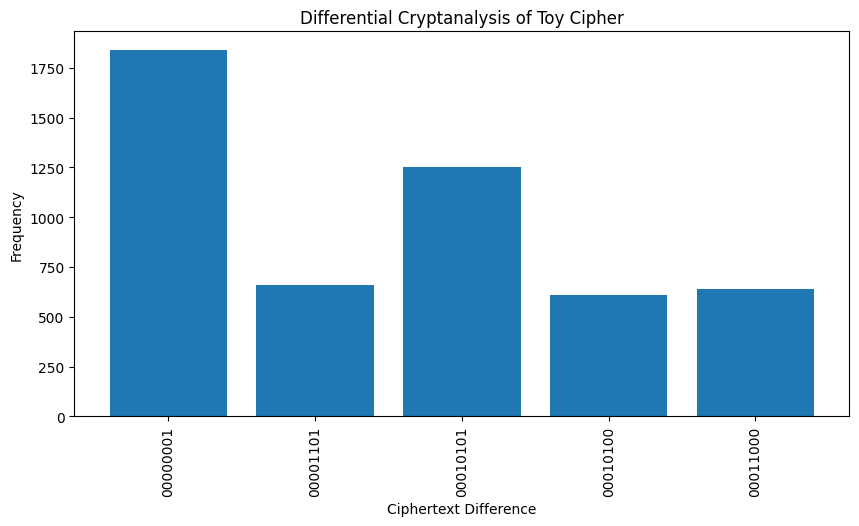

In [7]:
import matplotlib.pyplot as plt

x = list(diff_counts.keys())
y = list(diff_counts.values())

plt.figure(figsize=(10,5))
plt.bar([format(i,'08b') for i in x], y)

plt.xticks(rotation=90)

plt.xlabel("Ciphertext Difference")
plt.ylabel("Frequency")
plt.title("Differential Cryptanalysis of Toy Cipher")

plt.show()

## Conclusion

The experiment demonstrates how **differential cryptanalysis** can reveal statistical biases in block ciphers.

By analyzing how input differences propagate through the cipher, attackers may identify patterns that reduce the effective security of the algorithm. Although the toy cipher used here is intentionally simple, the same principles apply to real-world cryptographic analysis.